In [1]:
import os

import numpy as np
from IPython.core.pylabtools import figsize
from PIL.ImageColor import colormap
from astropy.coordinates.matrix_utilities import rotation_matrix
from matplotlib import pyplot as plt
from matplotlib.pyplot import subplots
from matplotlib import rcParams
from scipy.constants import mu_0
from tudatpy import constants
from tudatpy.data import save2txt
from tudatpy.interface import spice
from tudatpy.dynamics import environment_setup, propagation_setup, simulator
from tudatpy.astro import element_conversion


In [2]:
rcParams['font.family'] = 'Times New Roman'
rcParams['font.size'] = 12
rcParams['axes.titlesize'] = 10
rcParams['axes.labelsize'] = 10
rcParams['xtick.labelsize'] = 8
rcParams['ytick.labelsize'] = 8
rcParams['legend.fontsize'] = 9

In [3]:
palette = {
    "pastel_blue"   : "#6AA7FF",
    "pastel_pink"   : "#FF82A9",
    "pastel_green"  : "#7ED6A6",
    "pastel_purple" : "#A894E8",
    "pastel_orange" : "#FFB27C",
    "pastel_teal"   : "#63D2C6"
}

In [4]:
# Retrieve current directory
current_directory = os.getcwd()

# student number: 1244779 --> 1244ABC
A = 4
B = 2
C = 6

In [5]:
simulation_start_epoch = (
    35.4 * constants.JULIAN_YEAR
    + A * 7.0 * constants.JULIAN_DAY
    + B * constants.JULIAN_DAY
    + C * constants.JULIAN_DAY / 24.0
)
simulation_end_epoch = simulation_start_epoch + 344.0 * constants.JULIAN_DAY / 24.0


In [6]:
def propagator_q4(central_body = 'Jupiter', perturbation = False):

    # Load spice kernels.
    spice.load_standard_kernels()
    spice.load_kernel(current_directory + "/juice_mat_crema_5_1_150lb_v01.bsp")

    # Create settings for celestial bodies
    if perturbation == True:
        bodies_to_create = ["Ganymede", "Jupiter", "Sun", "Saturn", "Europa", "Io", "Callisto"]
    else:
        if central_body == "Jupiter":
            bodies_to_create = [central_body, "Ganymede"]
        else:
            bodies_to_create = [central_body]


    global_frame_origin = central_body
    global_frame_orientation = "ECLIPJ2000"
    body_settings = environment_setup.get_default_body_settings(
        bodies_to_create, global_frame_origin, global_frame_orientation

    )




    reference_area = 100.0                                  # m2
    drag_coefficient = 1.2
    radiation_pressure_coefficient = 1.2                    # kg
    density_scale_height = 40e3                             # m
    density_at_zero_alt = 2e-9                              # kg/m3

    if perturbation == True:
        body_settings.add_empty_settings("JUICE")

        body_settings.get("Ganymede").atmosphere_settings = environment_setup.atmosphere.exponential(density_at_zero_alt, density_scale_height)

        # Create environment
        bodies = environment_setup.create_system_of_bodies(body_settings)
        bodies.get_body('JUICE').mass = 2000.0

        aero_coefficient_settings = environment_setup.aerodynamic_coefficients.constant(reference_area,[drag_coefficient,0.0,0.0])

        environment_setup.add_aerodynamic_coefficient_interface(bodies, "JUICE", aero_coefficient_settings)

        occulting_bodies = ["Ganymede"]
        radiation_pressure_settings = environment_setup.radiation_pressure.cannonball("Sun", reference_area, radiation_pressure_coefficient, occulting_bodies)

        environment_setup.add_radiation_pressure_interface(bodies, "JUICE", radiation_pressure_settings)

    else:
        body_settings.add_empty_settings("JUICE")
        # Create environment
        bodies = environment_setup.create_system_of_bodies(body_settings)




    # Define bodies that are propagated, and their central bodies of propagation.
    bodies_to_propagate = ["JUICE"]
    central_bodies = [central_body]

    # Define accelerations acting on vehicle.
    if perturbation == True:
        # Define accelerations acting on vehicle.
        acceleration_settings_on_vehicle = {
        'Ganymede' :
        [
        propagation_setup.acceleration.spherical_harmonic_gravity(2,2),
        propagation_setup.acceleration.aerodynamic()
        ],

        'Jupiter' :
        [
        propagation_setup.acceleration.spherical_harmonic_gravity(4,0)
        ],

        'Sun' :
        [
        propagation_setup.acceleration.point_mass_gravity(),
        propagation_setup.acceleration.cannonball_radiation_pressure()
        ],

        'Saturn' :
        [
        propagation_setup.acceleration.point_mass_gravity()
        ],

        'Europa' :
        [
        propagation_setup.acceleration.point_mass_gravity()
        ],

        'Io' :
        [
        propagation_setup.acceleration.point_mass_gravity()
        ],

        'Callisto' :
        [
        propagation_setup.acceleration.point_mass_gravity()
        ]
    }
    else:
          acceleration_settings_on_vehicle = {
              'Ganymede' :  [propagation_setup.acceleration.point_mass_gravity()]
          }

    # Create global accelerations dictionary.
    acceleration_settings = {"JUICE": acceleration_settings_on_vehicle}

    # Create acceleration models.
    acceleration_models = propagation_setup.create_acceleration_models(
        bodies, acceleration_settings, bodies_to_propagate, central_bodies
    )

    # Define initial state.
    if central_body == "Ganymede":
        system_initial_state = spice.get_body_cartesian_state_at_epoch(
            target_body_name="JUICE",
            observer_body_name="Ganymede",
            reference_frame_name="ECLIPJ2000",
            aberration_corrections="NONE",
            ephemeris_time=simulation_start_epoch,
        )
    elif central_body == "Jupiter":
        x_Gs = spice.get_body_cartesian_state_at_epoch(
            target_body_name="JUICE",
            observer_body_name="Ganymede",
            reference_frame_name="ECLIPJ2000",
            aberration_corrections="NONE",
            ephemeris_time=simulation_start_epoch,
        )
        x_JG = spice.get_body_cartesian_state_at_epoch(
            target_body_name="Ganymede",
            observer_body_name="Jupiter",
            reference_frame_name="ECLIPJ2000",
            aberration_corrections="NONE",
            ephemeris_time=simulation_start_epoch,
        )
        system_initial_state = x_Gs + x_JG

    # Define required outputs

    dependent_variables_to_save = [
        propagation_setup.dependent_variable.relative_position("JUICE", central_body),
        propagation_setup.dependent_variable.relative_velocity("JUICE", central_body),
    ]

    if central_body == "Jupiter":
        dependent_variables_to_save += [
            propagation_setup.dependent_variable.relative_position("Ganymede", "Jupiter"),
            propagation_setup.dependent_variable.relative_velocity("Ganymede", "Jupiter"),
    ]

    # Create numerical integrator settings.
    fixed_step_size = 10.0
    integrator_settings = propagation_setup.integrator.runge_kutta_fixed_step(
        fixed_step_size, coefficient_set=propagation_setup.integrator.CoefficientSets.rk_4
    )

    # Create propagation settings.
    termination_settings = propagation_setup.propagator.time_termination(
        simulation_end_epoch
    )
    propagator_settings = propagation_setup.propagator.translational(
        central_bodies,
        acceleration_models,
        bodies_to_propagate,
        system_initial_state,
        simulation_start_epoch,
        integrator_settings,
        termination_settings,
        output_variables=dependent_variables_to_save,
    )

    propagator_settings.print_settings.print_initial_and_final_conditions = True

    # Create simulation object and propagate dynamics.
    dynamics_simulator = simulator.create_dynamics_simulator(
        bodies, propagator_settings
    )

    # Retrieve all data produced by simulation
    propagation_results = dynamics_simulator.propagation_results

    # Extract numerical solution for states and dependent variables
    state_history = propagation_results.state_history
    dependent_variables = propagation_results.dependent_variable_history

    save2txt(
        solution=state_history, filename=f"JUICEPropagationHistory_{central_body}_Q4.dat", directory="./"
    )

    save2txt(
        solution=dependent_variables,
        filename="JUICEPropagationHistory_DependentVariables_Q1.dat",
        directory="./",
    )
    state_vector = np.vstack(list(dependent_variables.values()))
    r_Js = state_vector[:,0:3]
    v_Js = state_vector[:,3:6]


    time = dependent_variables.keys()
    time_days = [
        t / constants.JULIAN_DAY - simulation_start_epoch / constants.JULIAN_DAY
        for t in time
    ]

    results = { 'time': time,
                'time_days': time_days,
                'r_Js': r_Js,
                'v_Js': v_Js,}

    if central_body == "Jupiter":
        results['r_JG'] = state_vector[:,6:9]
        results['v_JG'] = state_vector[:,9:12]
        results['r_Gs'] = r_Js - state_vector[:,6:9]
        results['v_Gs'] = v_Js - state_vector[:,9:12]


    return results

In [7]:
#

In [8]:

# CASE 1 -Unperturbed, Ganymede-centered propagation - from Q1
res_i = propagator_q4(central_body = 'Ganymede')

# CASE 2 -Unperturbed, Jupiter-centered propagation - from q4
res_ii = propagator_q4(central_body = 'Jupiter')

# CASE 3 - Perturbed, Ganymede-centered propagation - from q2
res_iii = propagator_q4(central_body = 'Ganymede', perturbation = True)

# CASE4 -Perturbed, Jupiter-centered propagation - from que 4
res_iv = propagator_q4(central_body = 'Jupiter', perturbation = True)

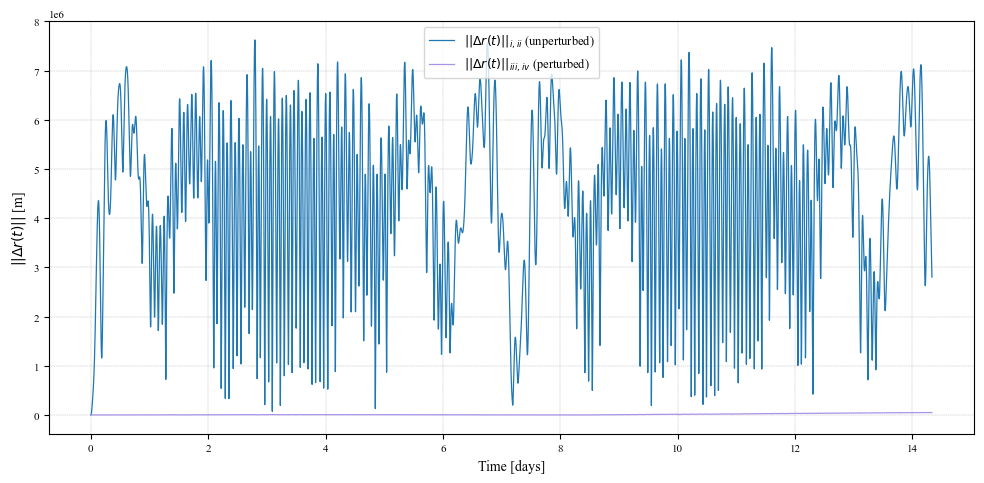

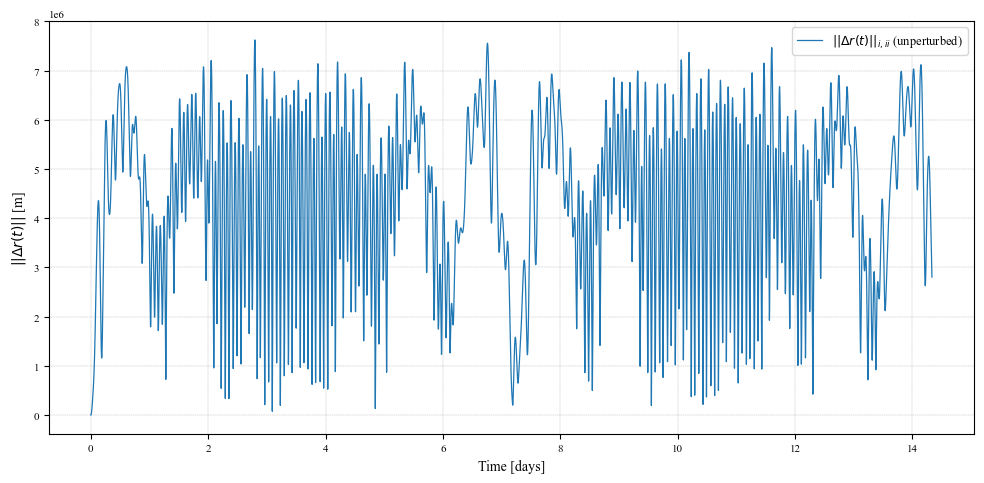

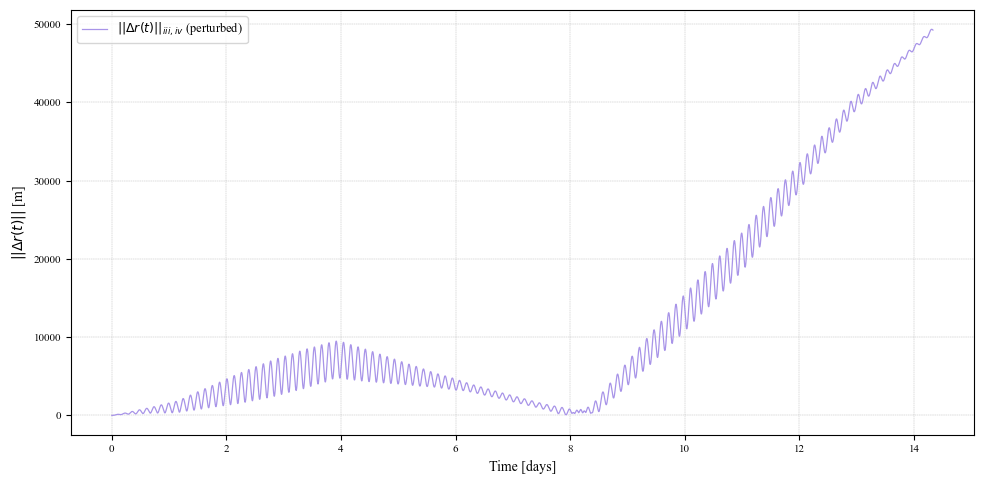

In [11]:
rGs_i   = np.array(res_i["r_Js"])
rGs_ii  = np.array(res_ii["r_Gs"])
rGs_iii = np.array(res_iii["r_Js"])
rGs_iv  = np.array(res_iv["r_Gs"])

dr_i_ii   = np.linalg.norm(rGs_i - rGs_ii, axis=1)
dr_iii_iv = np.linalg.norm(rGs_iii - rGs_iv, axis=1)

plt.figure(figsize=(10,5))
plt.plot(res_i['time_days'], dr_i_ii,   label=r"$||\Delta r(t)||_{i,ii}$ (unperturbed)", linewidth=0.9)
plt.plot(res_i['time_days'], dr_iii_iv, label=r"$||\Delta r(t)||_{iii,iv}$ (perturbed)", linewidth=0.9, color = palette["pastel_purple"])
plt.xlabel("Time [days]")
plt.ylabel(r"$||\Delta r(t)||$ [m]")
plt.grid(True, linestyle="--", linewidth=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(res_i['time_days'], dr_i_ii,   label=r"$||\Delta r(t)||_{i,ii}$ (unperturbed)", linewidth=0.9)
plt.xlabel("Time [days]")
plt.ylabel(r"$||\Delta r(t)||$ [m]")
plt.grid(True, linestyle="--", linewidth=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(res_i['time_days'], dr_iii_iv, label=r"$||\Delta r(t)||_{iii,iv}$ (perturbed)", linewidth=0.9, color = palette["pastel_purple"])
plt.xlabel("Time [days]")
plt.ylabel(r"$||\Delta r(t)||$ [m]")
plt.grid(True, linestyle="--", linewidth=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [54]:
def propagator_q4_last(perturbation = False):

    # Load spice kernels.
    spice.load_standard_kernels()
    spice.load_kernel(current_directory + "/juice_mat_crema_5_1_150lb_v01.bsp")

    # Create settings for celestial bodies

    bodies_to_create = ["Ganymede", "Jupiter", "Sun", "Saturn", "Europa", "Io", "Callisto"]
   

    global_frame_origin = 'Jupiter'
    global_frame_orientation = "ECLIPJ2000"
    body_settings = environment_setup.get_default_body_settings(
        bodies_to_create, global_frame_origin, global_frame_orientation

    )




    reference_area = 100.0                                  # m2
    drag_coefficient = 1.2
    radiation_pressure_coefficient = 1.2                    # kg
    density_scale_height = 40e3                             # m
    density_at_zero_alt = 2e-9                              # kg/m3

    body_settings.add_empty_settings("JUICE")
    if perturbation == True:
       
        body_settings.get("Ganymede").atmosphere_settings = environment_setup.atmosphere.exponential(density_at_zero_alt, density_scale_height)

        # Create environment
        bodies = environment_setup.create_system_of_bodies(body_settings)
        bodies.get_body('JUICE').mass = 2000.0

        aero_coefficient_settings = environment_setup.aerodynamic_coefficients.constant(reference_area,[drag_coefficient,0.0,0.0])
        environment_setup.add_aerodynamic_coefficient_interface(bodies, "JUICE", aero_coefficient_settings)

        occulting_bodies = ["Ganymede"]
        radiation_pressure_settings = environment_setup.radiation_pressure.cannonball("Sun", reference_area, radiation_pressure_coefficient, occulting_bodies)
        environment_setup.add_radiation_pressure_interface(bodies, "JUICE", radiation_pressure_settings)
        bodies_to_propagate = ["JUICE", "Ganymede"]
        central_bodies = ["Ganymede", "Jupiter"]
        
    else:
        bodies = environment_setup.create_system_of_bodies(body_settings)
        bodies_to_propagate = ["JUICE", "Ganymede"]
        central_bodies = ["Jupiter", "Jupiter"]
        bodies.get_body('JUICE').mass = 2000.0






    if perturbation == True:
        # Define accelerations acting on vehicle.

        acceleration_settings_on_vehicle = {
        'Ganymede' :
        [
        propagation_setup.acceleration.spherical_harmonic_gravity(2,2),
        propagation_setup.acceleration.aerodynamic()
        ],

        'Jupiter' :
        [
        propagation_setup.acceleration.spherical_harmonic_gravity(4,0)
        ],

        'Sun' :
        [
        propagation_setup.acceleration.point_mass_gravity(),
        propagation_setup.acceleration.cannonball_radiation_pressure()
        ],

        'Saturn' :
        [
        propagation_setup.acceleration.point_mass_gravity()
        ],

        'Europa' :
        [
        propagation_setup.acceleration.point_mass_gravity()
        ],

        'Io' :
        [
        propagation_setup.acceleration.point_mass_gravity()
        ],

        'Callisto' :
        [
        propagation_setup.acceleration.point_mass_gravity()
        ]
        }

        # acceleration settings on ganymede
        acceleration_settings_on_ganymede = {

        'Jupiter' :
        [
        propagation_setup.acceleration.spherical_harmonic_gravity(4,0)
        ],

        'Sun' :
        [
        propagation_setup.acceleration.point_mass_gravity(),
        ],

        'Saturn' :
        [
        propagation_setup.acceleration.point_mass_gravity()
        ],

        'Europa' :
        [
        propagation_setup.acceleration.point_mass_gravity()
        ],

        'Io' :
        [
        propagation_setup.acceleration.point_mass_gravity()
        ],

        'Callisto' :
        [
        propagation_setup.acceleration.point_mass_gravity()
        ]
        }

    else:
        # Define accelerations acting on vehicle.

        acceleration_settings_on_vehicle = {
        'Jupiter' :
        [
        propagation_setup.acceleration.spherical_harmonic_gravity(4,0)
        ]
        }

        acceleration_settings_on_ganymede = {

        'Jupiter' :
        [
        propagation_setup.acceleration.spherical_harmonic_gravity(4,0)
        ]
        }



    # Create global accelerations dictionary.
    acceleration_settings = {"JUICE": acceleration_settings_on_vehicle, "Ganymede": acceleration_settings_on_ganymede}
    # Create acceleration models.
    acceleration_models = propagation_setup.create_acceleration_models(bodies, acceleration_settings, bodies_to_propagate, central_bodies)



    # Define initial state.
    if perturbation == True:
        x_sG= spice.get_body_cartesian_state_at_epoch(
            target_body_name="JUICE",
            observer_body_name="Ganymede",
            reference_frame_name="ECLIPJ2000",
            aberration_corrections="NONE",
            ephemeris_time=simulation_start_epoch,
        )

        x_GJ = spice.get_body_cartesian_state_at_epoch(
            target_body_name="Ganymede",
            observer_body_name="Jupiter",
            reference_frame_name="ECLIPJ2000",
            aberration_corrections="NONE",
            ephemeris_time=simulation_start_epoch,
        )
        system_initial_state = np.concatenate([x_sG, x_GJ])
    else:
        x_sJ = spice.get_body_cartesian_state_at_epoch(
            target_body_name="JUICE",
            observer_body_name="Jupiter",
            reference_frame_name="ECLIPJ2000",
            aberration_corrections="NONE",
            ephemeris_time=simulation_start_epoch,
        )
        
        x_GJ = spice.get_body_cartesian_state_at_epoch(
            target_body_name="Ganymede",
            observer_body_name="Jupiter",
            reference_frame_name="ECLIPJ2000",
            aberration_corrections="NONE",
            ephemeris_time=simulation_start_epoch,
        )
    
        system_initial_state = np.concatenate([x_sJ, x_GJ])


    # Define required outputs
    if perturbation == True:
        dependent_variables_to_save = [
            propagation_setup.dependent_variable.relative_position("JUICE", 'Ganymede'),
            propagation_setup.dependent_variable.relative_velocity("JUICE", 'Ganymede'),

            propagation_setup.dependent_variable.relative_position("Ganymede", "Jupiter"),
            propagation_setup.dependent_variable.relative_velocity("Ganymede", "Jupiter"),
        ]
    else:
        dependent_variables_to_save = [
            propagation_setup.dependent_variable.relative_position("JUICE", 'Jupiter'),
            propagation_setup.dependent_variable.relative_velocity("JUICE", 'Jupiter'),

            propagation_setup.dependent_variable.relative_position("Ganymede", "Jupiter"),
            propagation_setup.dependent_variable.relative_velocity("Ganymede", "Jupiter"),
        ]


    # Create numerical integrator settings.
    fixed_step_size = 10.0
    integrator_settings = propagation_setup.integrator.runge_kutta_fixed_step(
        fixed_step_size, coefficient_set=propagation_setup.integrator.CoefficientSets.rk_4
    )

    # Create propagation settings.
    termination_settings = propagation_setup.propagator.time_termination(
        simulation_end_epoch
    )
    propagator_settings = propagation_setup.propagator.translational(
        central_bodies,
        acceleration_models,
        bodies_to_propagate,
        system_initial_state,
        simulation_start_epoch,
        integrator_settings,
        termination_settings,
        output_variables=dependent_variables_to_save,
    )

    propagator_settings.print_settings.print_initial_and_final_conditions = True

    # Create simulation object and propagate dynamics.
    dynamics_simulator = simulator.create_dynamics_simulator(
        bodies, propagator_settings
    )

    # Retrieve all data produced by simulation
    propagation_results = dynamics_simulator.propagation_results

    # Extract numerical solution for states and dependent variables
    state_history = propagation_results.state_history
    dependent_variables = propagation_results.dependent_variable_history

    save2txt(
        solution=state_history, filename=f"JUICEPropagationHistoryQ4C.dat",directory="./"
    )

    save2txt(
        solution=dependent_variables,
        filename="JUICEPropagationHistory_DependentVariablesQ4C.dat",
        directory="./",
    )
    state_vector = np.vstack(list(dependent_variables.values()))



    time = dependent_variables.keys()
    time_days = [
        t / constants.JULIAN_DAY - simulation_start_epoch / constants.JULIAN_DAY
        for t in time
    ]

    results = { 'time': time,
                'time_days': time_days,
                'state_vector': state_vector,}

    if perturbation == True:
        results['r_sG'] = state_vector[:,0:3]
        results['v_sG'] = state_vector[:,3:6]
        results['r_GJ'] = state_vector[:,6:9]
        results['v_GJ'] = state_vector[:,9:12]
    else:
        results['r_sJ'] = state_vector[:,0:3]
        results['v_sJ'] = state_vector[:,3:6]
        results['r_GJ'] = state_vector[:,6:9]
        results['v_GJ'] = state_vector[:,9:12]



    return results

In [48]:
que_4c_results_II = propagator_q4_last(perturbation=False)
que_4c_results_IV = propagator_q4_last(perturbation=True)


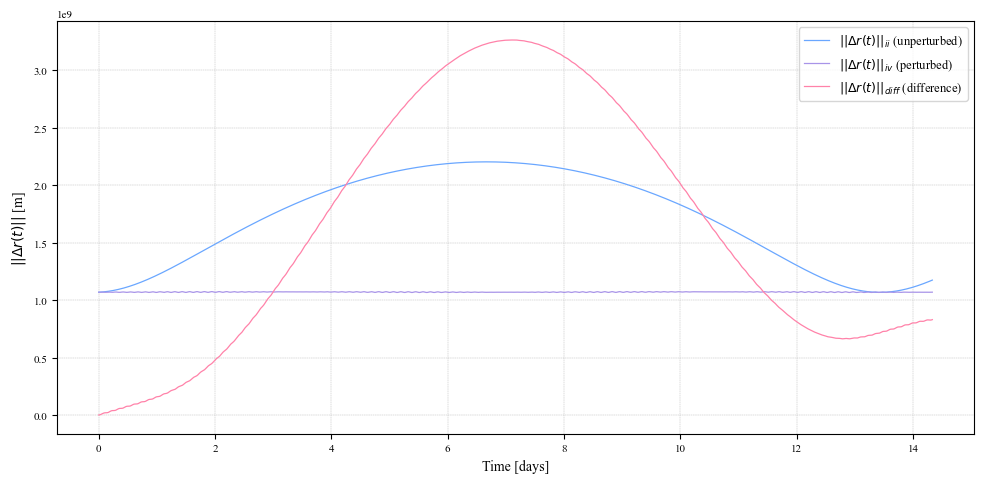

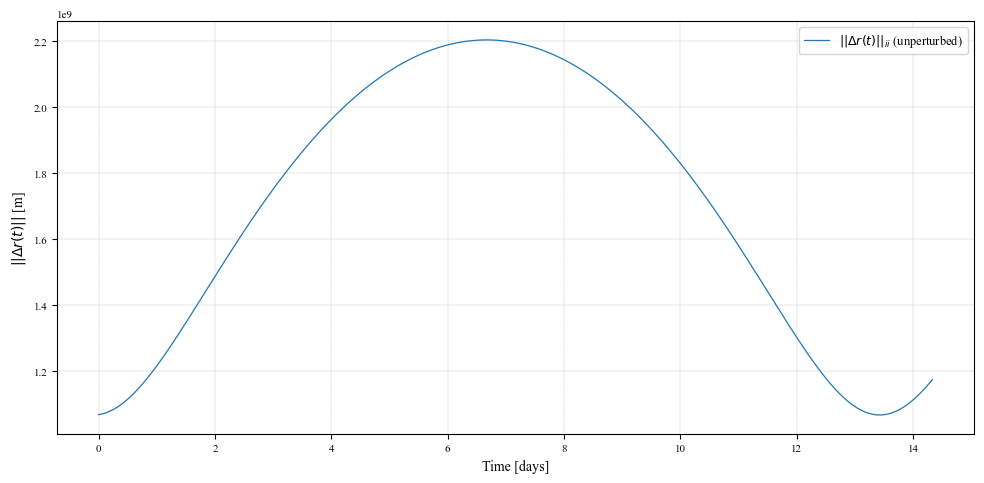

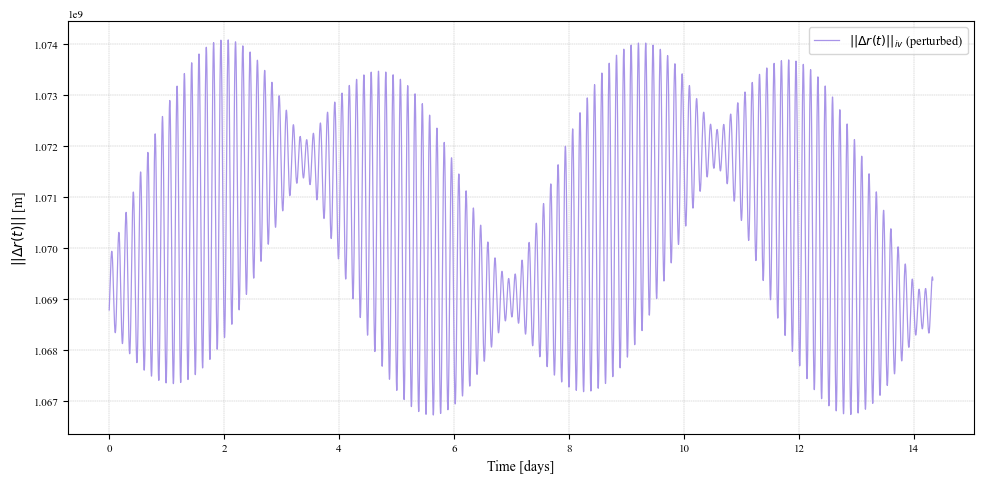

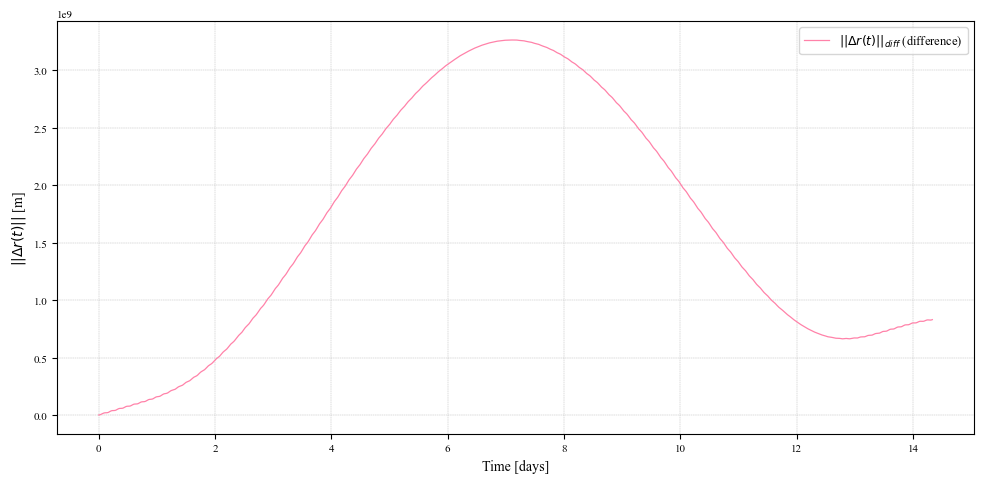

In [56]:

res_iv  = np.array(que_4c_results_IV["r_sG"]+ que_4c_results_IV["r_GJ"])

res_ii  = np.array(que_4c_results_II["r_sJ"])


dr_ii   = np.linalg.norm(res_ii, axis=1)
dr_iv = np.linalg.norm(res_iv, axis=1)
dr_diff = np.linalg.norm(res_iv - res_ii, axis=1)

plt.figure(figsize=(10,5))
plt.plot(que_4c_results_II['time_days'], dr_ii,   label=r"$||\Delta r(t)||_{ii}$ (unperturbed)", linewidth=0.9, color = palette["pastel_blue"])
plt.plot(que_4c_results_IV['time_days'], dr_iv, label=r"$||\Delta r(t)||_{iv}$ (perturbed)", linewidth=0.9, color = palette["pastel_purple"])
plt.plot(que_4c_results_IV['time_days'], dr_diff, label=r"$||\Delta r(t)||_{diff}$ (difference)", linewidth=0.9, color = palette["pastel_pink"])
plt.xlabel("Time [days]")
plt.ylabel(r"$||\Delta r(t)||$ [m]")
plt.grid(True, linestyle="--", linewidth=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(que_4c_results_II['time_days'], dr_ii,   label=r"$||\Delta r(t)||_{ii}$ (unperturbed)", linewidth=0.9)
plt.xlabel("Time [days]")
plt.ylabel(r"$||\Delta r(t)||$ [m]")
plt.grid(True, linestyle="--", linewidth=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(que_4c_results_IV['time_days'], dr_iv, label=r"$||\Delta r(t)||_{iv}$ (perturbed)", linewidth=0.9, color = palette["pastel_purple"])
plt.xlabel("Time [days]")
plt.ylabel(r"$||\Delta r(t)||$ [m]")
plt.grid(True, linestyle="--", linewidth=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(que_4c_results_IV['time_days'], dr_diff, label=r"$||\Delta r(t)||_{diff}$ (difference)", linewidth=0.9, color = palette["pastel_pink"])
plt.xlabel("Time [days]")
plt.ylabel(r"$||\Delta r(t)||$ [m]")
plt.grid(True, linestyle="--", linewidth=0.3)
plt.legend()
plt.tight_layout()
plt.show()

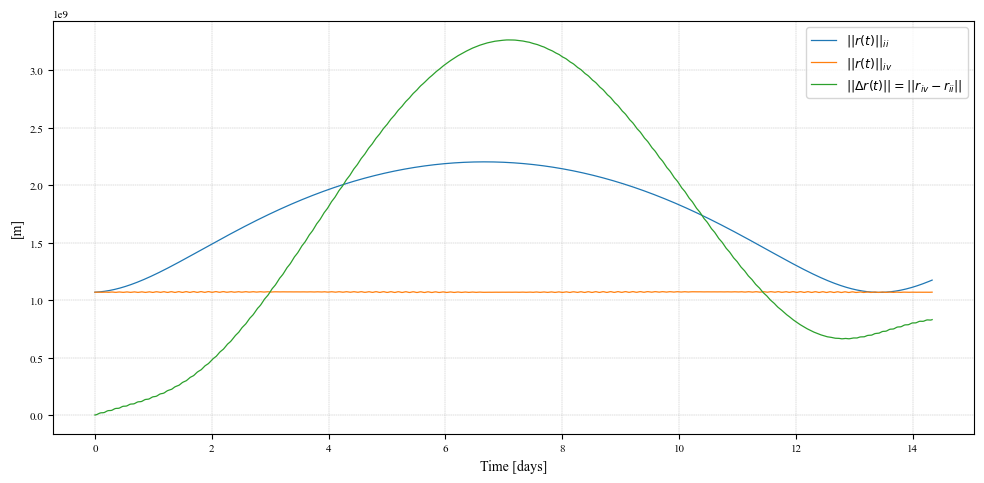

In [55]:
t = np.array(que_4c_results_II["time_days"])  # should match IV

plt.figure(figsize=(10,5))
plt.plot(t, np.linalg.norm(res_ii, axis=1), label=r"$||r(t)||_{ii}$", linewidth=0.9)
plt.plot(t, np.linalg.norm(res_iv, axis=1), label=r"$||r(t)||_{iv}$", linewidth=0.9)
plt.plot(t, dr_diff, label=r"$||\Delta r(t)|| = ||r_{iv}-r_{ii}||$", linewidth=0.9)
plt.xlabel("Time [days]")
plt.ylabel("[m]")
plt.grid(True, linestyle="--", linewidth=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
print("||Δr(0)|| =", np.linalg.norm(res_iv[0] - res_ii[0]))

||Δr(0)|| = 1.862645149230957e-08
